# X-Ray Binary Classification with ResNet-18 (PyTorch)
Classifies chest X-rays into **No Finding** vs **Finding** using a fine-tuned ResNet-18 backbone.

**Dataset:** NIH Chest X-Ray14 (`Data_Entry_2017.csv` + image folders)

Labels are collapsed to:
- `0` → No Finding
- `1` → Finding (any record which isnt 'No finding')

In [2]:
import os
import numpy as np
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report

# Reproducibility
torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cpu


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#!mkdir -p /content/drive/MyDrive/xray-dataset/

In [5]:
#!kaggle datasets download -d nih-chest-xrays/data/ --path /content/drive/MyDrive/xray-dataset/

In [7]:
# delete images_006
#import shutil
#shutil.rmtree('../content/drive/MyDrive/xray-dataset/images_006')

#import os

print(os.listdir('../content/drive/MyDrive/xray-dataset/'))



['data.zip', 'images_003', 'images_004', 'images_005', 'Data_Entry_2017.csv', 'resnet18_xray_final.pth']


In [8]:
from glob import glob
import pandas as pd

csv_path = '../content/drive/MyDrive/xray-dataset/Data_Entry_2017.csv'
print("CSV exists:", os.path.exists(csv_path))

df = pd.read_csv(csv_path)
print("CSV rows:", df.shape[0])        # should be ~112,000
print("Columns:", df.columns.tolist())

images = glob('../content/drive/MyDrive/xray-dataset/images*/*/*.png')
print("Images found:", len(images))    # should be ~112,000

CSV exists: True
CSV rows: 112120
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


KeyboardInterrupt: 

Path: ../content/drive/MyDrive/xray-dataset/images_005/images/00009469_000.png
Size: (1024, 1024)
Mode: L


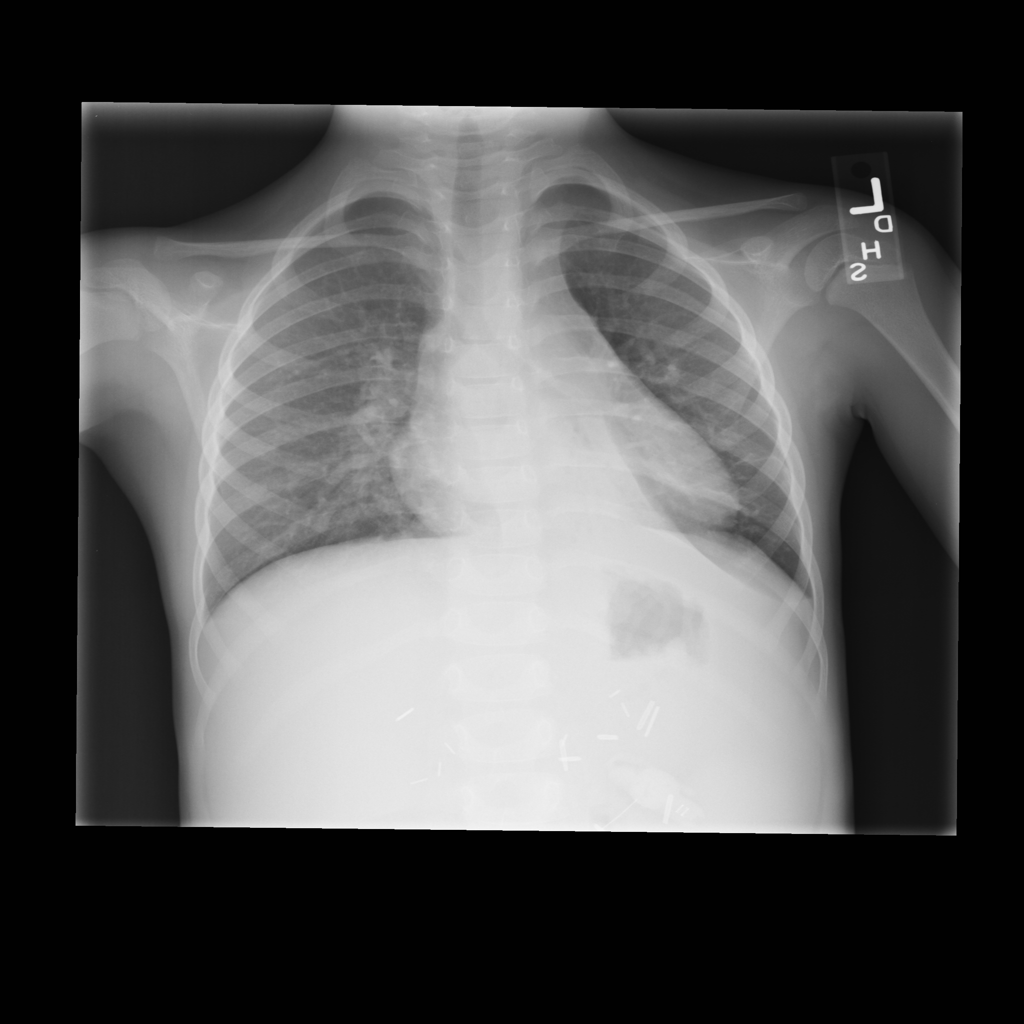

In [ ]:
from PIL import Image
# open random image
test_img = np.random.choice(images)
img = Image.open(test_img)
print("Path:", test_img)
print("Size:", img.size)       # e.g. (1024, 1024)
print("Mode:", img.mode)       # should be L (grayscale) or RGB
img

## 1. Load Metadata

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_CSV   = '../content/drive/MyDrive/xray-dataset/Data_Entry_2017.csv'
IMAGE_GLOB = os.path.join('..', 'content', 'drive', 'MyDrive', 'xray-dataset', 'images*', '*', '*.png')

all_xray_df = pd.read_csv(DATA_CSV)

# Map image filenames → full paths
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
print(f'Scans found: {len(all_image_paths)}, Total CSV rows: {all_xray_df.shape[0]}')

all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)

all_xray_df.sample(3)
all_xray_df.head()

Scans found: 29969, Total CSV rows: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,None
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,None
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,None
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,None
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,None


## 2. Label Engineering – Binary: No Finding vs Pneumonia

We keep only rows that are either:
- **No Finding** (label column is exactly `'No Finding'`), or
- **Findings** (label column that dont contain no findings)

This removes multi-label cases, giving the model a clean binary signal.

Class distribution:
binary_label
No Finding    17044
Finding       12925
Name: count, dtype: int64


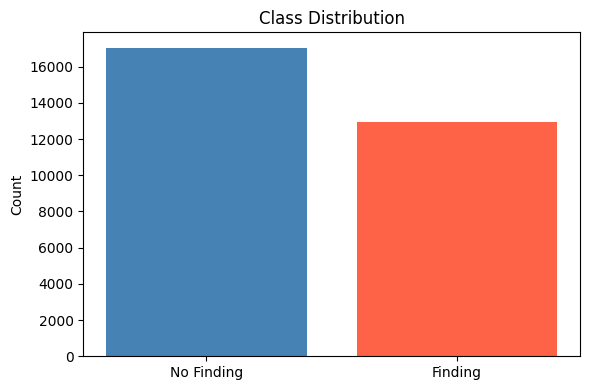

In [ ]:
def assign_binary_label(finding: str) -> int | None:
    """Return 0 for No Finding, 1 for Finding, None to drop."""
    if finding == 'No Finding':
        return 0
    else:
        return 1
    

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)

# Drop rows that don't belong to either class
binary_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
binary_df['binary_label'] = binary_df['binary_label'].astype(int)

print('Class distribution:')
counts = binary_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Finding'})
print(counts)

# Visualise
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 2a. Rebalance – optional downsampling
The NIH dataset has many more 'No Finding' cases. We downsample the majority class to 2× the minority class size to reduce bias without throwing away all negative examples.

In [ ]:
finding_df  = binary_df[binary_df['binary_label'] == 1]
no_finding_df = binary_df[binary_df['binary_label'] == 0]

# Downsample No Finding to 2× Pneumonia count
n_finding = len(finding_df)
no_finding_sampled = no_finding_df.sample(min(2 * n_finding, len(no_finding_df)), random_state=42)

balanced_df = pd.concat([finding_df, no_finding_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Balanced dataset size:', len(balanced_df))
print(balanced_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Finding'}))

Balanced dataset size: 29969
binary_label
No Finding    17044
Finding       12925
Name: count, dtype: int64


## 3. Train / Validation / Test Split

In [ ]:
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    random_state=42,
    stratify=balanced_df['binary_label']
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['binary_label']
)

print(f'Train: {len(train_df)}  |  Val: {len(valid_df)}  |  Test: {len(test_df)}')

Train: 20978  |  Val: 4495  |  Test: 4496


## 4. Dataset & DataLoaders

- Images are loaded as **RGB** (ResNet-18 expects 3 channels).
- Training uses standard augmentations; validation/test use only resize + normalise.
- Normalisation uses ImageNet statistics (mean/std) because ResNet-18 was pre-trained on ImageNet.

In [ ]:
IMG_SIZE   = 224   # ResNet-18 default input size
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class XRayDataset(Dataset):
    """Chest X-Ray binary dataset (No Finding vs Pneumonia)."""

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = torch.tensor(row['binary_label'], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = XRayDataset(train_df, transform=train_transforms)
valid_dataset = XRayDataset(valid_df, transform=eval_transforms)
test_dataset  = XRayDataset(test_df,  transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'Batches — train: {len(train_loader)}  val: {len(valid_loader)}  test: {len(test_loader)}')

Batches — train: 656  val: 141  test: 141


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### 4a. Visualise a batch

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


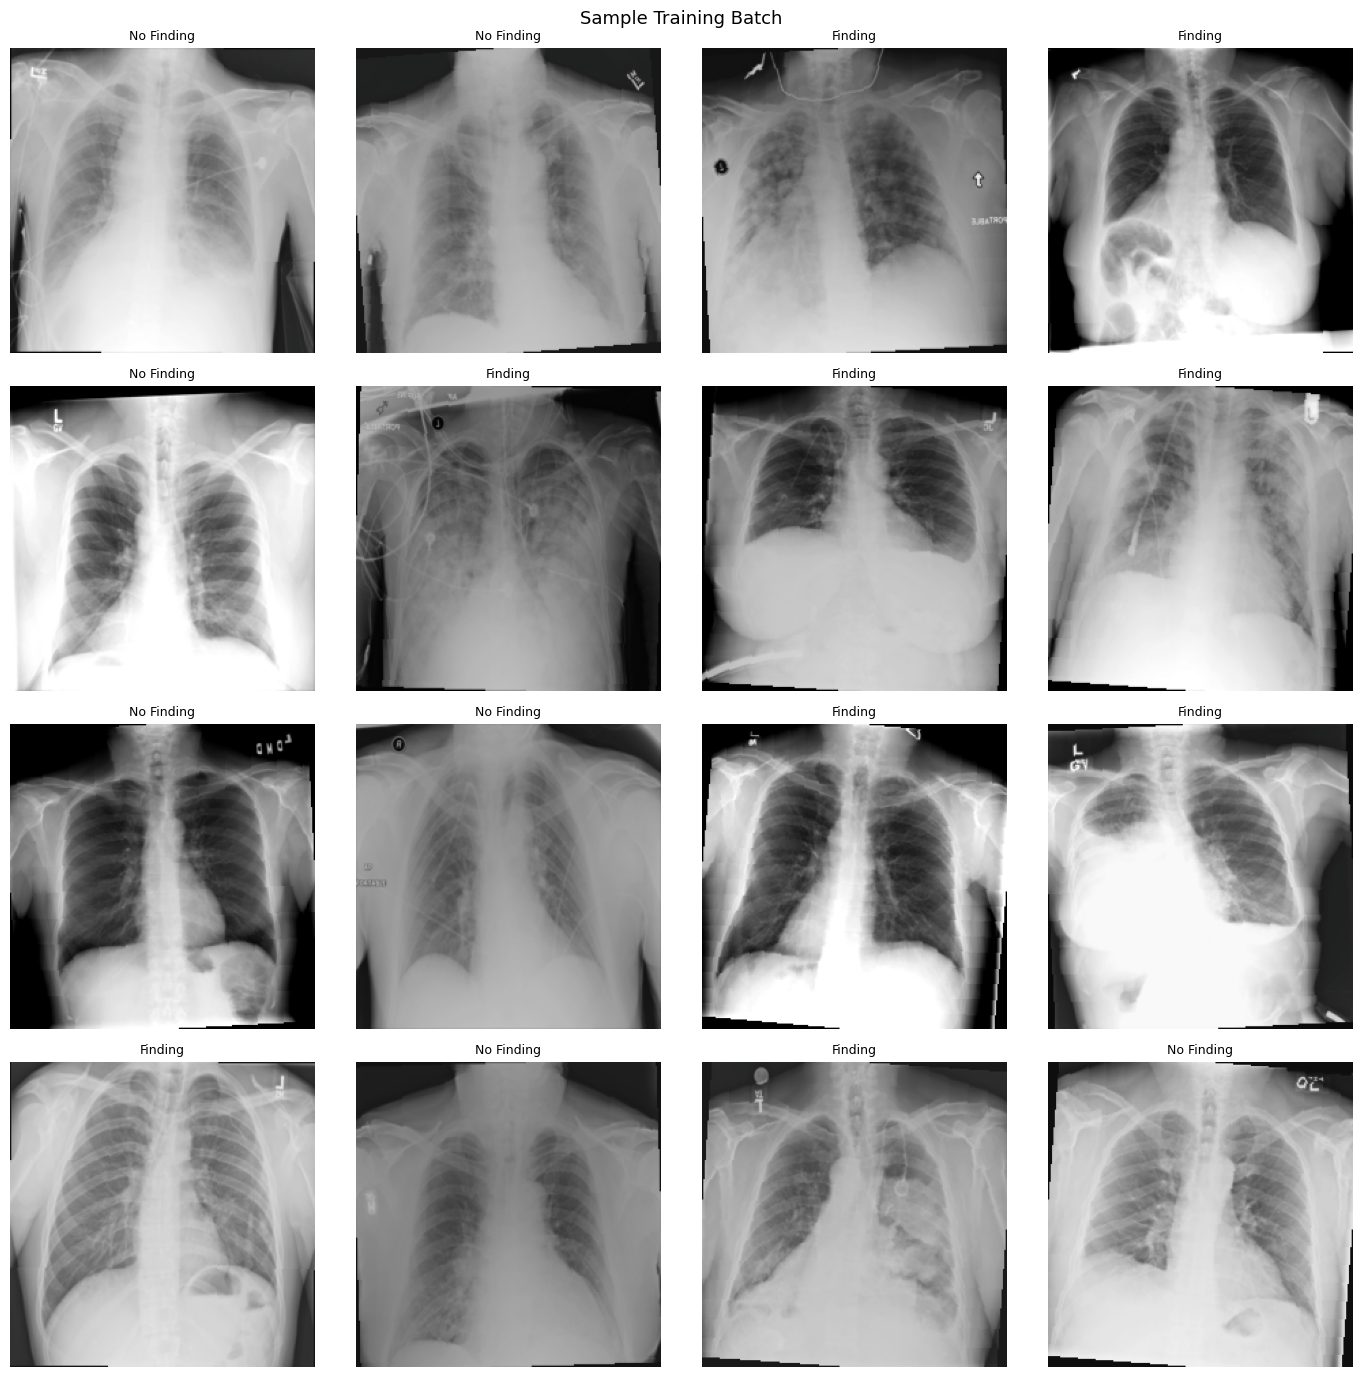

In [ ]:
CLASS_NAMES = {0: 'No Finding', 1: 'Finding'}

images, labels = next(iter(train_loader))

def denormalise(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, img, lbl in zip(axes.flatten(), images[:16], labels[:16]):
    img_np = denormalise(img).permute(1, 2, 0).numpy()
    ax.imshow(img_np, cmap='bone')
    ax.set_title(CLASS_NAMES[int(lbl.item())], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Batch', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Build ResNet-18 Model

We load ImageNet pre-trained weights and replace the final fully-connected layer with a **single neuron + sigmoid** for binary classification. The rest of the network is fine-tuned.

In [ ]:
def build_resnet18(freeze_backbone: bool = False) -> nn.Module:
    """
    ResNet-18 with a custom binary classification head.

    Args:
        freeze_backbone: If True, only the classification head is trained
                         (useful for a warm-up phase).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = True

    # Replace the default 1000-class head
    in_features = model.fc.in_features   # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, 1),               # single output
        nn.Sigmoid()
    )

    return model

model = build_resnet18(freeze_backbone=False).to(DEVICE)

# Quick sanity check
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print('Output shape:', out.shape)   # should be [2, 1]

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}  |  Trainable: {trainable_params:,}')

Output shape: torch.Size([2, 1])
Total params: 11,308,097  |  Trainable: 11,308,097


## 6. Loss, Optimiser & Scheduler

We use **BCELoss** (binary cross-entropy) with `pos_weight` to further compensate for any remaining class imbalance.

In [ ]:
# Compute positive class weight from training set
n_neg = (train_df['binary_label'] == 0).sum()
n_pos = (train_df['binary_label'] == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_weight.item():.3f}  (neg={n_neg}, pos={n_pos})')

criterion = nn.BCELoss(weight=None)   # sigmoid is already in the model
# Alternatively: nn.BCEWithLogitsLoss(pos_weight=pos_weight) if you remove Sigmoid from the head

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Reduce LR on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)

pos_weight: 1.319  (neg=11931, pos=9047)


## 7. Training Loop

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total   += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total   += images.size(0)

        all_preds.append(outputs.cpu())
        all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return total_loss / total, correct / total, all_preds, all_labels

In [ ]:
NUM_EPOCHS    = 10
BEST_VAL_LOSS = float('inf')
CHECKPOINT    = 'resnet18_xray_best.pth'
PATIENCE      = 4
patience_ctr  = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc, _, _ = evaluate(model, valid_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    improved = val_loss < BEST_VAL_LOSS
    if improved:
        BEST_VAL_LOSS = val_loss
        torch.save(model.state_dict(), CHECKPOINT)
        patience_ctr = 0
    else:
        patience_ctr += 1

    flag = ' ← best' if improved else ''
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping after {epoch} epochs.')
        break

print('\nTraining complete. Best val_loss:', round(BEST_VAL_LOSS, 4))

Epoch 01/10  train_loss=0.6140  train_acc=0.6709  val_loss=0.5826  val_acc=0.7099 ← best
Epoch 02/10  train_loss=0.5901  train_acc=0.6957  val_loss=0.5711  val_acc=0.7130 ← best
Epoch 03/10  train_loss=0.5813  train_acc=0.7033  val_loss=0.5718  val_acc=0.7059
Epoch 04/10  train_loss=0.5695  train_acc=0.7120  val_loss=0.5621  val_acc=0.7190 ← best
Epoch 05/10  train_loss=0.5640  train_acc=0.7153  val_loss=0.5670  val_acc=0.7128
Epoch 06/10  train_loss=0.5535  train_acc=0.7222  val_loss=0.5807  val_acc=0.7141
Epoch 07/10  train_loss=0.5433  train_acc=0.7295  val_loss=0.5745  val_acc=0.7139
Epoch 08/10  train_loss=0.4994  train_acc=0.7609  val_loss=0.5919  val_acc=0.7159
Early stopping after 8 epochs.

Training complete. Best val_loss: 0.5621


## 8. Training Curves

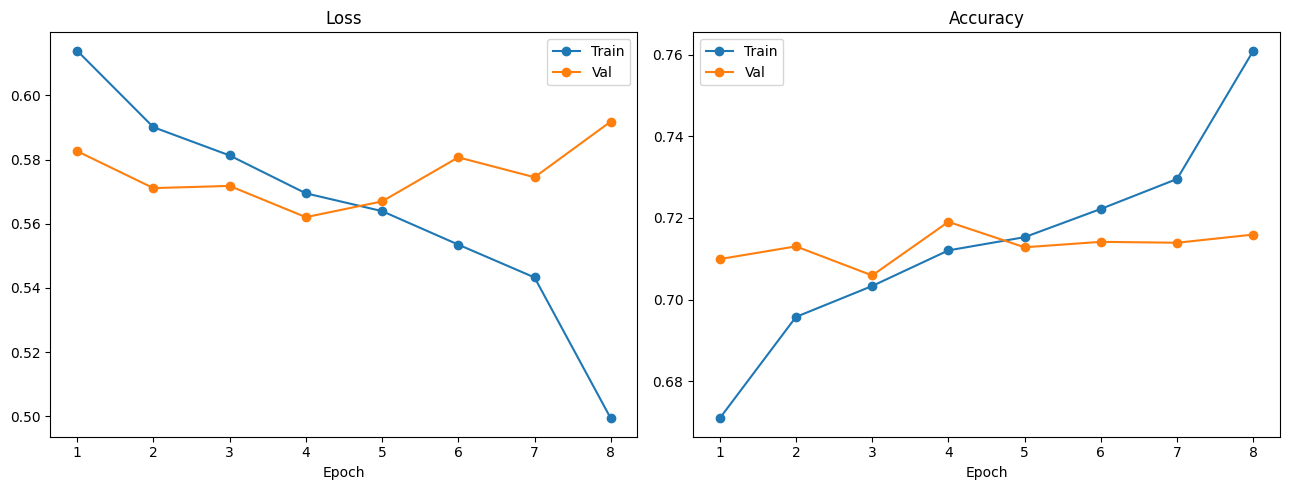

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs_ran, history['train_loss'], label='Train', marker='o')
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   marker='o')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs_ran, history['train_acc'], label='Train', marker='o')
ax2.plot(epochs_ran, history['val_acc'],   label='Val',   marker='o')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

## 9. Evaluate on Test Set

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))

test_loss, test_acc, pred_probs, true_labels = evaluate(model, test_loader, criterion, DEVICE)
pred_binary = (pred_probs >= 0.5).astype(int)

print(f'Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}\n')
print(classification_report(true_labels.astype(int), pred_binary,
                             target_names=['No Finding', 'Finding']))

Test Loss: 0.5730  |  Test Accuracy: 0.7006

              precision    recall  f1-score   support

  No Finding       0.74      0.73      0.74      2557
     Finding       0.65      0.66      0.66      1939

    accuracy                           0.70      4496
   macro avg       0.70      0.70      0.70      4496
weighted avg       0.70      0.70      0.70      4496



## 10. ROC Curve

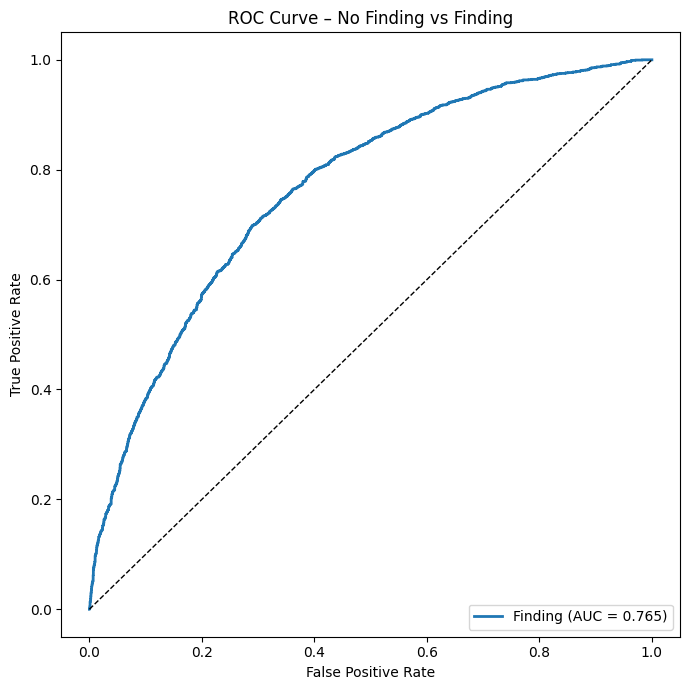

In [ ]:
fpr, tpr, _ = roc_curve(true_labels.astype(int), pred_probs)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, label=f'Finding (AUC = {roc_auc:.3f})', lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve – No Finding vs Finding')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

## 11. Show Predictions on Sample Images

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


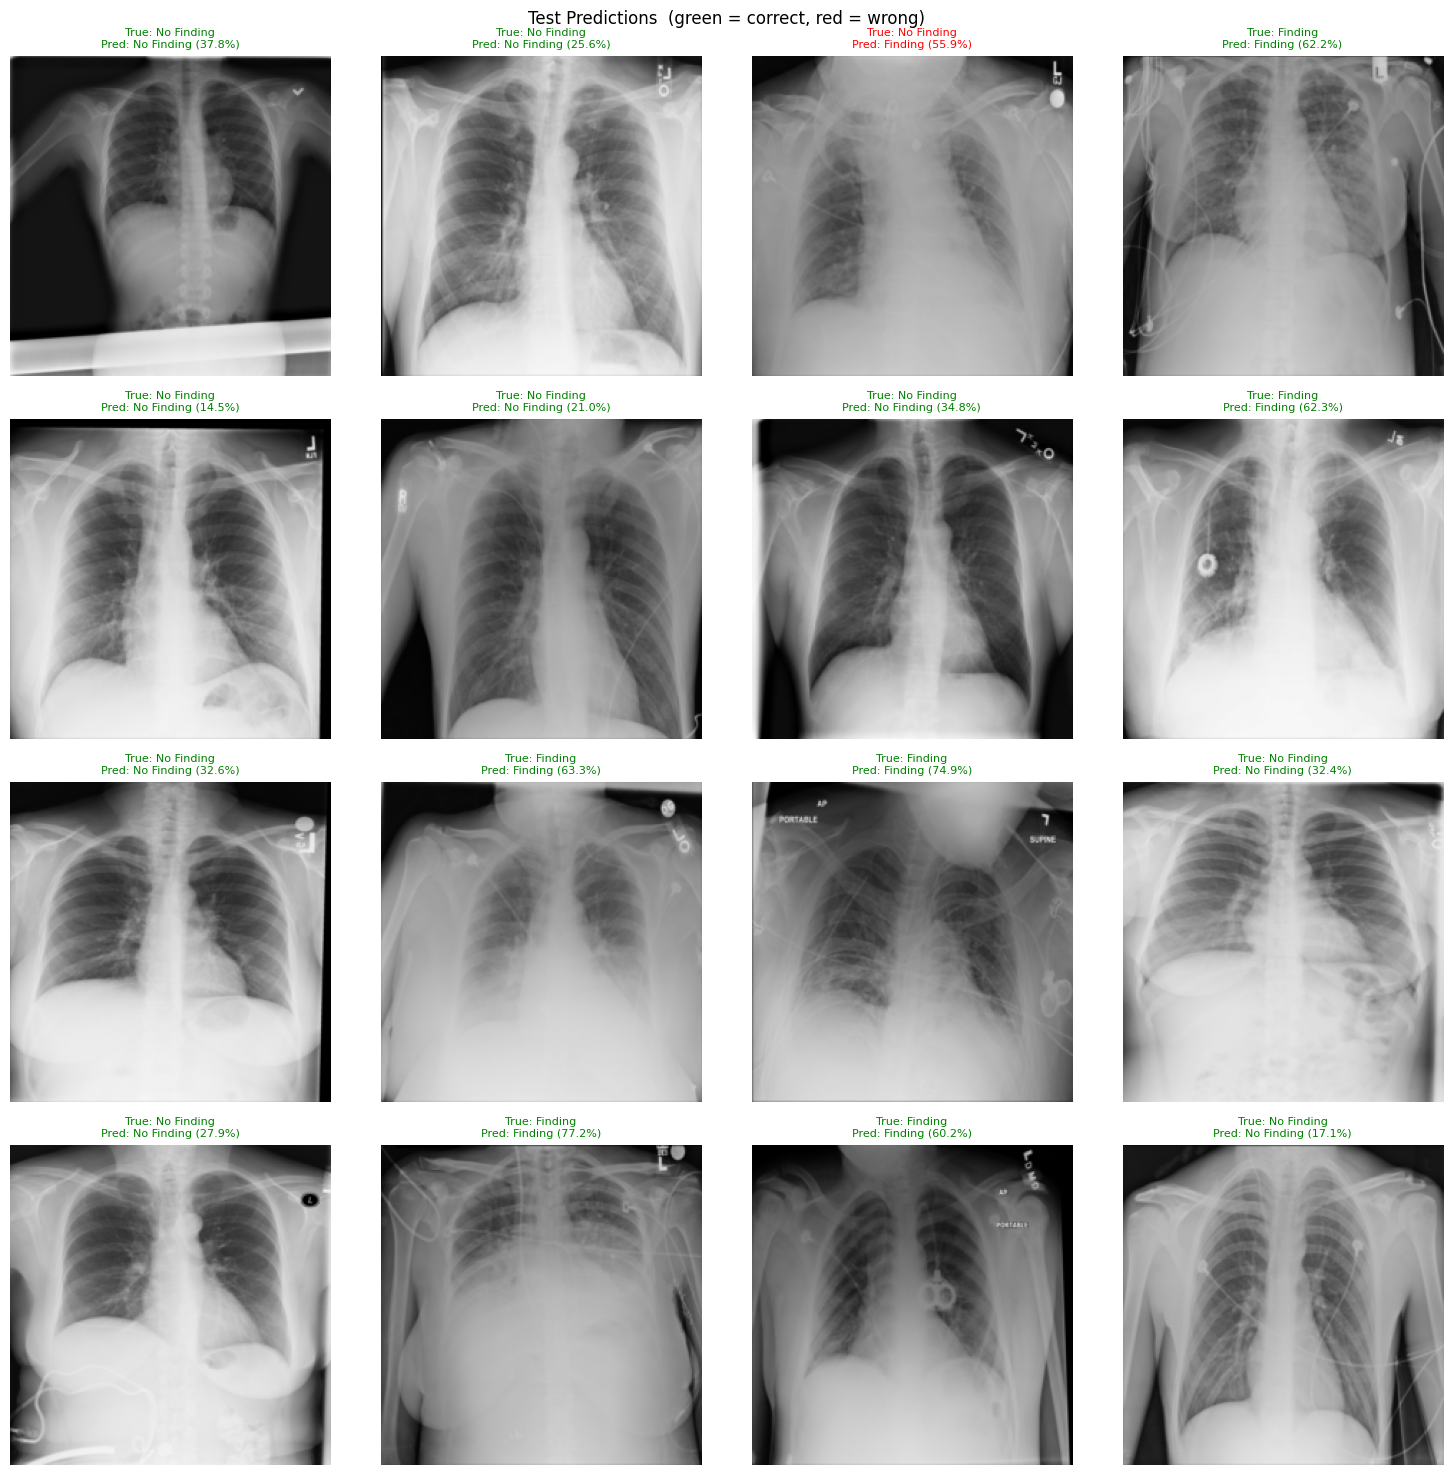

In [ ]:
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images_dev = sample_images.to(DEVICE)

with torch.no_grad():
    sample_probs = model(sample_images_dev).cpu().squeeze().numpy()

n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(15, 15))

for ax, img, true_lbl, prob in zip(axes.flatten(),
                                    sample_images[:n_show],
                                    sample_labels[:n_show],
                                    sample_probs[:n_show]):
    img_np    = denormalise(img).permute(1, 2, 0).numpy()
    pred_lbl  = int(prob >= 0.5)
    true_str  = CLASS_NAMES[int(true_lbl.item())]
    pred_str  = CLASS_NAMES[pred_lbl]
    colour    = 'green' if pred_lbl == int(true_lbl.item()) else 'red'

    ax.imshow(img_np, cmap='bone')
    ax.set_title(f'True: {true_str}\nPred: {pred_str} ({prob:.1%})',
                 color=colour, fontsize=8)
    ax.axis('off')

plt.suptitle('Test Predictions  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=120)
plt.show()

## 12. Save the Final Model

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'img_size':         IMG_SIZE,
    'test_accuracy':    round(test_acc, 4),
    'test_auc':         round(roc_auc, 4),
}, '/content/drive/MyDrive/xray-dataset/resnet18_xray_final.pth')

print('Model saved to /content/drive/MyDrive/xray-dataset/resnet18_xray_final.pth')

Model saved to /content/drive/MyDrive/xray-dataset/resnet18_xray_final.pth
